
![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/notebooks_banner_withframe.png)

# Imbalanced species data, background points, and weighting methods - Part 2

Author details: Xiang Zhao

Editor details: Dr Sebastian Lopez Marcano

Contact details: support\@ecocommons.org.au

Copyright statement: This script is the product of the EcoCommons platform. Please refer to the EcoCommons website for more details: <https://www.ecocommons.org.au/>

Date: April 2025

# Script and data info

This notebook is the continuation of the notebook ['**Part 1: Imbalanced species data, background points, and weighting methods'**](https://ecocommonsaustralia.github.io/notebook-blog/notebooks/data_prep/imbalanced_data_part1.html#objectives-part-1)**.**

These two notebooks, developed by the EcoCommons team, showcases how to deal with imbalanced species datasets (presence and absence data) with weighting methods.

# Abstract (Part 1 and Part 2)

When building species distribution models, it is common to encounter imbalanced datasets. This may involve a large number of presence records and relatively few absence records, or, in the case of rare species, a substantial number of absence records but only a limited number of presence records.

When working with imbalanced datasets, models and predictions can be prone to several issues, including bias towards the majority class, misleading performance metrics, and reduced sensitivity to the minority class. This occurs because the model learns predominantly from the more frequent class, leading to poor generalisation for rare events ([Menardi & Torelli, 2014](https://doi.org/10.1007/s10618-012-0295-5)). Therefore, it is essential to address dataset imbalance to ensure fair and reliable predictions.

This notebook explores strategies to address the challenges posed by imbalanced species data in ecological modeling, particularly in Species Distribution Models (SDMs). It focuses on the use of background points and weighting methods to improve model performance when presence and absence data are disproportionate. This notebook examines the effectiveness of different pseudo-absence generation techniques, including random and buffered-random background point sampling, and applies weighting schemes to mitigate class imbalance. Using the Gang-gang Cockatoo (*Callocephalon fimbriatum*) as a case study, the analysis demonstrates the impact of these methods on model evaluation metrics such as AUROC, AUPR, F1-score, and TSS. This guide aims to equip ecologists and data scientists with practical approaches for handling imbalanced datasets, ensuring more accurate and reliable SDMs within the EcoCommons platform.

# Objectives (Part 2)

1.  Learn how to generate background points using two methods: completely random and buffered-random.
2.  Learn how to compare model performance using different methods for generating background points and pseudo-absence data.

# **Workflow Overview**

-   Set the working directory and load the necessary R packages. Create directories to store raw data files.

-   Data Download: Download prepared imbalanced dataset(s) from the EcoCommons Google Drive.

-   Produce background points and pseudo-absence points

-   Model evaluation and comparison.

# Set-up: R Environment and Packages

Some housekeeping before we start. This process might take some time as many packages needed to be installed.




## S.1 Set the working directory and create a folder for data.

Save the Quarto Markdown file (.QMD) to a folder of your choice, and then set the path to your folder as your working directory.

In [1]:

# Set the workspace to the current working directory

workspace <- getwd()  # Get the current working directory and store it in 'workspace'

# Increase the plot size by adjusting the options for plot dimensions in the notebook output
options(repr.plot.width = 16, repr.plot.height = 8)  # Sets width to 16 and height to 8 for larger plots



Ideally, you would use the **`renv`** package to create an isolated environment for installing all the required R packages used in this notebook. However, since installing **`renv`** and its dependencies can be time-consuming, we recommend trying this after the workshop.


In [2]:

# # Ensure "renv" package is installed
# if (!requireNamespace("renv", quietly = TRUE)) {
#   install.packages("renv")
# }
#
# # Check if renv has been initialised in the project
# if (!file.exists("renv/activate.R")) {
#   message("renv has not been initiated in this project. Initializing now...")
#   renv::init()  # Initialise renv if not already set up
# } else {
#   source("renv/activate.R")  # Activate the renv environment
#   message("renv is activated.")
# }
#
# # Check for the existence of renv.lock and restore the environment
# if (file.exists("renv.lock")) {
#   message("Restoring renv environment from renv.lock...")
#   renv::restore()
# } else {
#   message("No renv.lock file found in the current directory. Skipping restore.")
# }



## S.2 Install and load essential libraries.

Install and load R packages.


In [3]:

# Set CRAN mirror
options(repos = c(CRAN = "https://cran.rstudio.com/"))

# List of packages to check, install if needed, and load
packages <- c("dplyr", "reshape2", "terra", "sf", "googledrive", "ggplot2", "corrplot",
              "pROC", "dismo", "spatstat.geom", "patchwork", "biomod2", "PRROC",
              "leaflet", "car", "gridExtra", "htmltools", "RColorBrewer", "kableExtra",
              "tibble", "knitr", "kableExtra", "IRdisplay")

# Function to display a cat message
cat_message <- function(pkg, message_type) {
  if (message_type == "installed") {
    cat(paste0(pkg, " has been installed successfully!\n"))
  } else if (message_type == "loading") {
    cat(paste0(pkg, " is already installed and has been loaded!\n"))
  }
}

# Install missing packages and load them
for (pkg in packages) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    install.packages(pkg)
    cat_message(pkg, "installed")
  } else {
    cat_message(pkg, "loading")
  }
  library(pkg, character.only = TRUE)
}


# If you are using renv, you can snapshot the renv after loading all the packages.

#renv::snapshot()


dplyr is already installed and has been loaded!



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘plyr’




reshape2 has been installed successfully!


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



terra has been installed successfully!


...

kableExtra has been installed successfully!



Attaching package: ‘kableExtra’


The following object is masked from ‘package:dplyr’:

    group_rows




tibble is already installed and has been loaded!
knitr is already installed and has been loaded!



Attaching package: ‘knitr’


The following object is masked from ‘package:terra’:

    spin




kableExtra is already installed and has been loaded!
IRdisplay is already installed and has been loaded!



## S.3 Download case study datasets

We have prepared the following data and uploaded them to our Google Drive for your use:

-   **Species occurrence data:** Shapefile format (.shp)

-   **Environmental variables:** Stacked Raster format (.tif)

-   **Study area boundary:** Shapefile format (.shp)


In [4]:

# De-authenticate Google Drive to access public files
drive_deauth()

# Define Google Drive file ID and the path for downloading
zip_file_id <- "1GXOA330Ow2F7NqxdhuBfbz0a-CMT8DTb"

datafolder_path <- file.path(workspace)

# Create a local path for the zipped file
zip_file_path <- file.path(datafolder_path, "imbalanced_data.zip")

# Function to download a file with progress messages
download_zip_file <- function(file_id, file_path) {
  cat("Downloading zipped file...\n")
  drive_download(as_id(file_id), path = file_path, overwrite = TRUE)
  cat("Downloaded zipped file to:", file_path, "\n")
}

# Create local directory if it doesn't exist
if (!dir.exists(datafolder_path)) {
  dir.create(datafolder_path, recursive = TRUE)
}

# Download the zipped file
cat("Starting to download the zipped file...\n")
download_zip_file(zip_file_id, zip_file_path)

# Unzip the downloaded file
cat("Unzipping the file...\n")
unzip(zip_file_path, exdir = datafolder_path)
cat("Unzipped files to folder:", datafolder_path, "\n")


Starting to download the zipped file...


File downloaded:

• imbalanced_data.zip <id: 1GXOA330Ow2F7NqxdhuBfbz0a-CMT8DTb>

Saved locally as:

• /content/imbalanced_data.zip



Downloaded zipped file to: /content/imbalanced_data.zip 
Unzipping the file...
Unzipped files to folder: /content 


# 1. Introduction




## 1.1 Background points and Pseudo-absence points

When working with presence-only records for your study species, a common approach is to sample a relatively large number of random points from the study area. These random points are referred to as **background** or **pseudo-absence points** ([Valavi et al., 2022](https://doi.org/10.1002/ecm.1486)).

There are two common approaches to generating background points. The first involves **randomly selecting background points** from the entire extent of the study area, allowing observations to be compared against the full range of environmental conditions within that area ([Elith et al., 2006](https://doi.org/10.1111/j.2006.0906-7590.04596.x); [Phillips et al., 2006](https://doi.org/10.1016/j.ecolmodel.2005.03.026)). The second approach generates background points within a specified minimum-maximum radius around presence points—a method referred to as the **"disk" approach** in the EcoCommons platform.

For more information about background points and pseudo-absence data, please check out our support article: [**Absence Data**](https://support.ecocommons.org.au/support/solutions/articles/6000255789-absence-data).

Load the imbalanced_data.RData so that we can get all variables produced by the '**Imbalanced Data Notebook Part 1**'.


In [5]:

# Load all variables from the saved workspace
file_id <- "1ZlUJml6kqO1jgAU7y1NmXi2iN5IDvUr-"

drive_download(as_id(file_id), path = "imbalanceddata_part1.RData", overwrite = TRUE)

load("imbalanceddata_part1.RData")


File downloaded:

• imbalanceddata_part1.RData <id: 1ZlUJml6kqO1jgAU7y1NmXi2iN5IDvUr->

Saved locally as:

• imbalanceddata_part1.RData




# 2. Background points and pseudo-absence points

In Chapter 3, we examined the scenario where true-absence data is included in the training dataset. However, researchers often lack access to true-absence data when training models, or they may opt to reserve this valuable data for cross-validation purposes, as demonstrated by [Elith et al. 2006](https://doi.org/10.1111/j.2006.0906-7590.04596.x) and [Valavi et al. 2022](https://doi.org/10.1002/ecm.1486).

So, what alternatives do we have when true-absence data is unavailable for training? One common approach is to generate background or pseudo-absence points and include them in the training dataset as substitutes for true-absence data.

For instance, if we allocate all true-absence data, along with an equal number of presence records, to the test dataset, and use the remaining data for training, we would have 272 rows in the test dataset (136 true absences and 136 presences) and 646 rows in the training dataset. This results in an approximate 30/70 split between test and training data.


In [6]:

 # Identify indices for ABSENCE and PRESENCE rows
  abs_idx <- which(gang_gang_act$occrrnS == "ABSENT")
  pres_idx <- which(gang_gang_act$occrrnS == "PRESENT")

  # Number of ABSENCE rows
  n_abs <- length(abs_idx)

  # Set seed for reproducibility and sample PRESENCE rows
  set.seed(123)
  pres_sample_idx <- sample(pres_idx, n_abs)

  # Create subdataframe 1: all ABSENCE rows + sampled PRESENCE rows
  test_data <- gang_gang_act[c(abs_idx, pres_sample_idx), ]

  # Create subdataframe 2: the remaining rows
  train_data <- gang_gang_act[-c(abs_idx, pres_sample_idx), ]


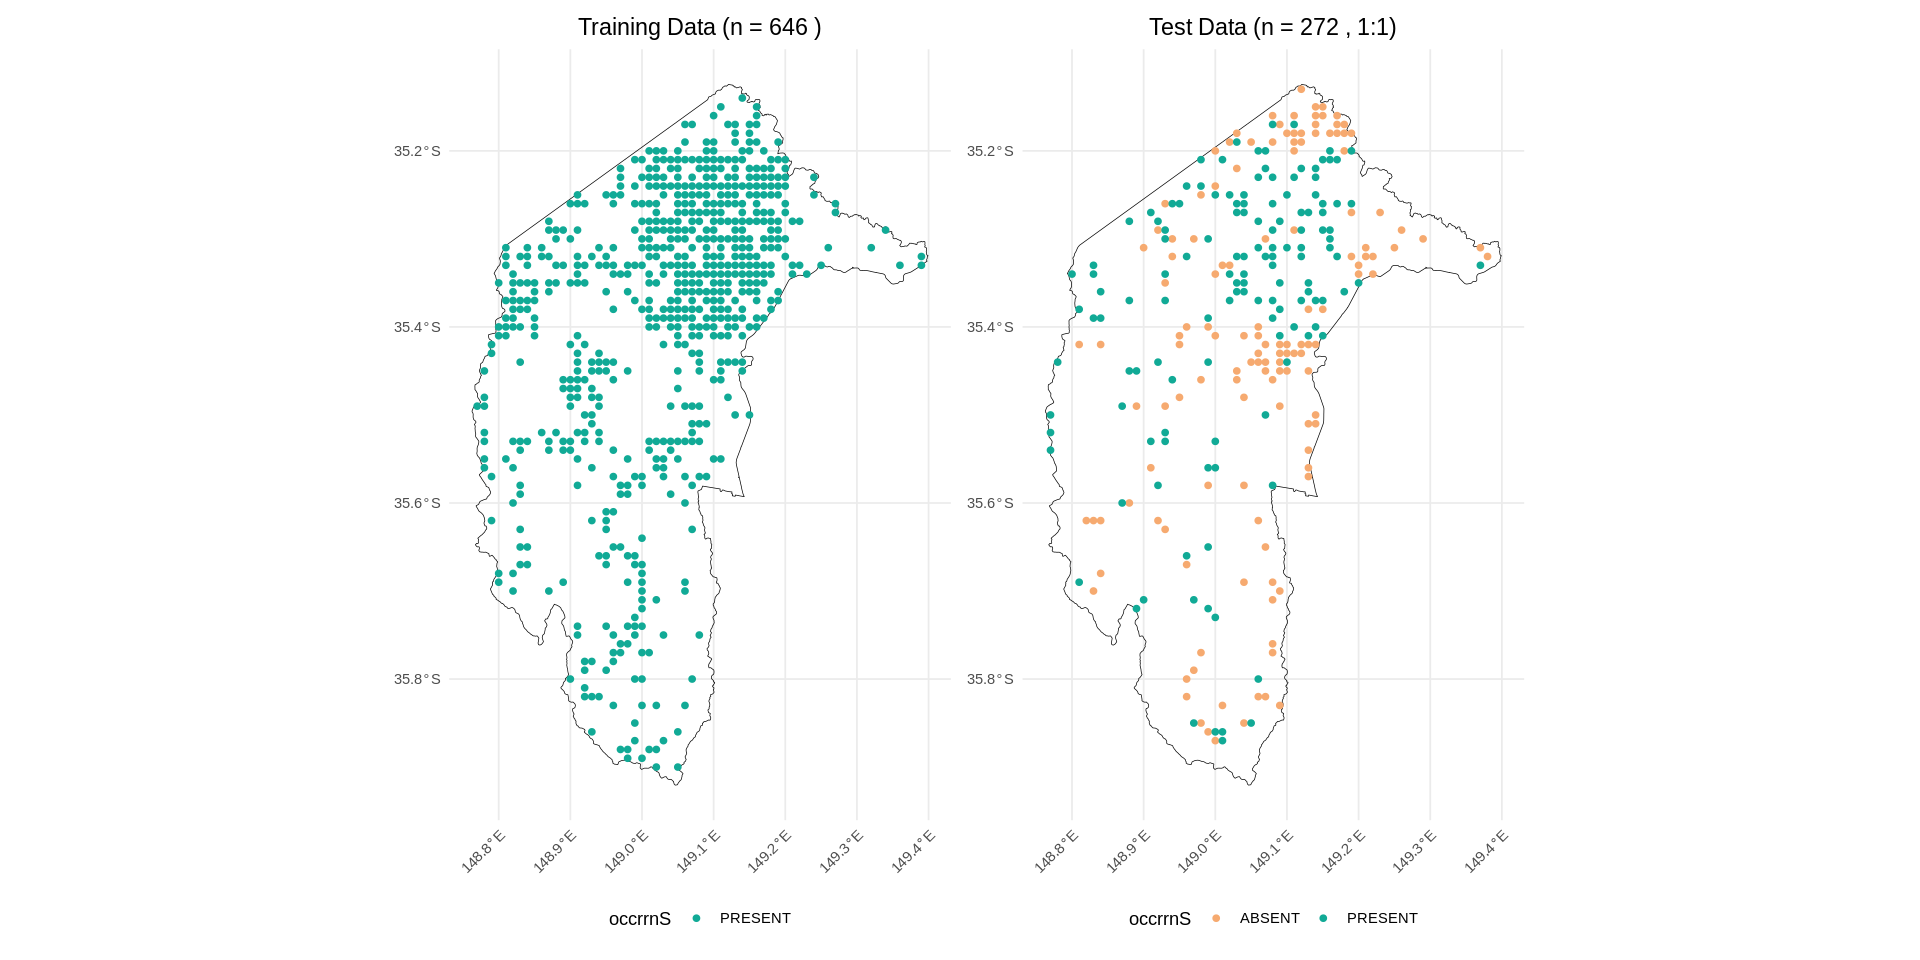

In [7]:

# Get bounding box from the ACT boundary
act_bbox <- sf::st_bbox(ACT)

# Count the number of points in train and test datasets
n_train <- nrow(train_data)
n_test <- nrow(test_data)

# Create ggplot for the training data with count annotation
p_train <- ggplot() +
  geom_sf(data = ACT, fill = NA, color = "black") +
  geom_sf(data = train_data, aes(color = occrrnS)) +
  scale_color_manual(values = c("PRESENT" = "#11aa96", "ABSENT" = "#f6aa70")) +
  ggtitle(paste("Training Data (n =", n_train, ")")) +  # Add count to title
  coord_sf(
    xlim = c(act_bbox["xmin"], act_bbox["xmax"]),
    ylim = c(act_bbox["ymin"], act_bbox["ymax"])
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom"
  )

# Create ggplot for the test data with count annotation
p_test <- ggplot() +
  geom_sf(data = ACT, fill = NA, color = "black") +
  geom_sf(data = test_data, aes(color = occrrnS)) +
  scale_color_manual(values = c("PRESENT" = "#11aa96", "ABSENT" = "#f6aa70")) +
  ggtitle(paste("Test Data (n =", n_test, ", 1:1)")) +  # Add count to title
  coord_sf(
    xlim = c(act_bbox["xmin"], act_bbox["xmax"]),
    ylim = c(act_bbox["ymin"], act_bbox["ymax"])
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom"
  )

# Combine the two plots side-by-side
combined_plot <- p_train + p_test + patchwork::plot_layout(ncol = 2)
combined_plot


## 2.1 Random background points

Many studies suggest that the number of background points should be sufficient to comprehensively sample and represent all environments in the study area, or at least a range of background point sizes should be tested. For example, [Valavi et al. 2022](https://doi.org/10.1002/ecm.1486) tested their models with 100 to 100,000 background points. [Barbet-Massin et al. 2012](https://doi.org/10.1111/j.2041-210X.2011.00172.x) tested 100, 300, 1000, 3000 or 10000 background points.

We here will also test the effect of different sizes of background points on the performance of models. We will test the ratio of background points to true presences from 1:1, 5:1, 10:1, 15:1, 20:1, 30:1, and 50:1 with and without weighting methods.

This is the function generating required number of random background points within the extent of the study area.


In [8]:

# Convert SpatRaster to Raster
# Load the stacked raster layers
env_var_stack <- rast("imbalanced_data/ACT_raster.tif")

# Select the desired layers by their names
selected_layers <- c("AusClim_bioclim_03_9s_1976-2005",
                     "AusClim_bioclim_06_9s_1976-2005",
                     "AusClim_bioclim_09_9s_1976-2005",
                     "AusClim_bioclim_15_9s_1976-2005",
                     "AusClim_bioclim_24_9s_1976-2005",
                     "AusClim_bioclim_27_9s_1976-2005",
                     "AusClim_bioclim_29_9s_1976-2005")

# Subset the raster stack
selected_rasters <- env_var_stack[[selected_layers]]

studyarea <- raster(env_var_stack$`AusClim_bioclim_01_9s_1976-2005`)

# Count the number of presence points in train_data (assuming presence is coded as 1)
n_pres <- nrow(train_data)

# Set seed for reproducibility
set.seed(1963)

# Generate background points with a 1:1 ratio
random_bg_1to1 <- randomPoints(studyarea, n_pres)

# Generate background points with a 5:1 ratio
random_bg_5to1 <- randomPoints(studyarea, n_pres * 5)

# Generate background points with a 10:1 ratio
random_bg_10to1 <- randomPoints(studyarea, n_pres * 10)

# Generate background points with a 15:1 ratio
random_bg_15to1 <- randomPoints(studyarea, n_pres * 15)

# Generate background points with a 20:1 ratio
random_bg_20to1 <- randomPoints(studyarea, n_pres * 20)

# Generate background points with a 30:1 ratio
random_bg_30to1 <- randomPoints(studyarea, n_pres * 30)

# Generate background points with a 100:1 ratio
random_bg_50to1 <- randomPoints(studyarea, n_pres * 50)


In [9]:

combine_bg_with_presence <- function(bg_points, train_data, raster_obj, target_crs = 4283, occ_label = "bg") {
  # Convert the background points matrix to a data frame
  bg_df <- as.data.frame(bg_points)

  # Add the occrrnS column with the specified label (e.g., "bg")
  bg_df$occrrnS <- occ_label

  # Convert the data frame to an sf object using the raster's projection
  bg_sf <- st_as_sf(bg_df, coords = c("x", "y"), crs = projection(raster_obj))

  # Transform the sf object to the target CRS (default is EPSG:4283)
  bg_sf_target <- st_transform(bg_sf, crs = target_crs)

  # Combine the original (presence) data with the background points
  combined <- rbind(train_data, bg_sf_target)

  return(combined)
}



We then combine the generated background points with true present data.


In [10]:

combined_random_bg_1to1 <- combine_bg_with_presence(random_bg_1to1, train_data, studyarea)
combined_random_bg_5to1 <- combine_bg_with_presence(random_bg_5to1, train_data, studyarea)
combined_random_bg_10to1 <- combine_bg_with_presence(random_bg_10to1, train_data, studyarea)
combined_random_bg_15to1 <- combine_bg_with_presence(random_bg_15to1, train_data, studyarea)
combined_random_bg_20to1 <- combine_bg_with_presence(random_bg_20to1, train_data, studyarea)
combined_random_bg_30to1 <- combine_bg_with_presence(random_bg_30to1, train_data, studyarea)
combined_random_bg_50to1 <- combine_bg_with_presence(random_bg_50to1, train_data, studyarea)

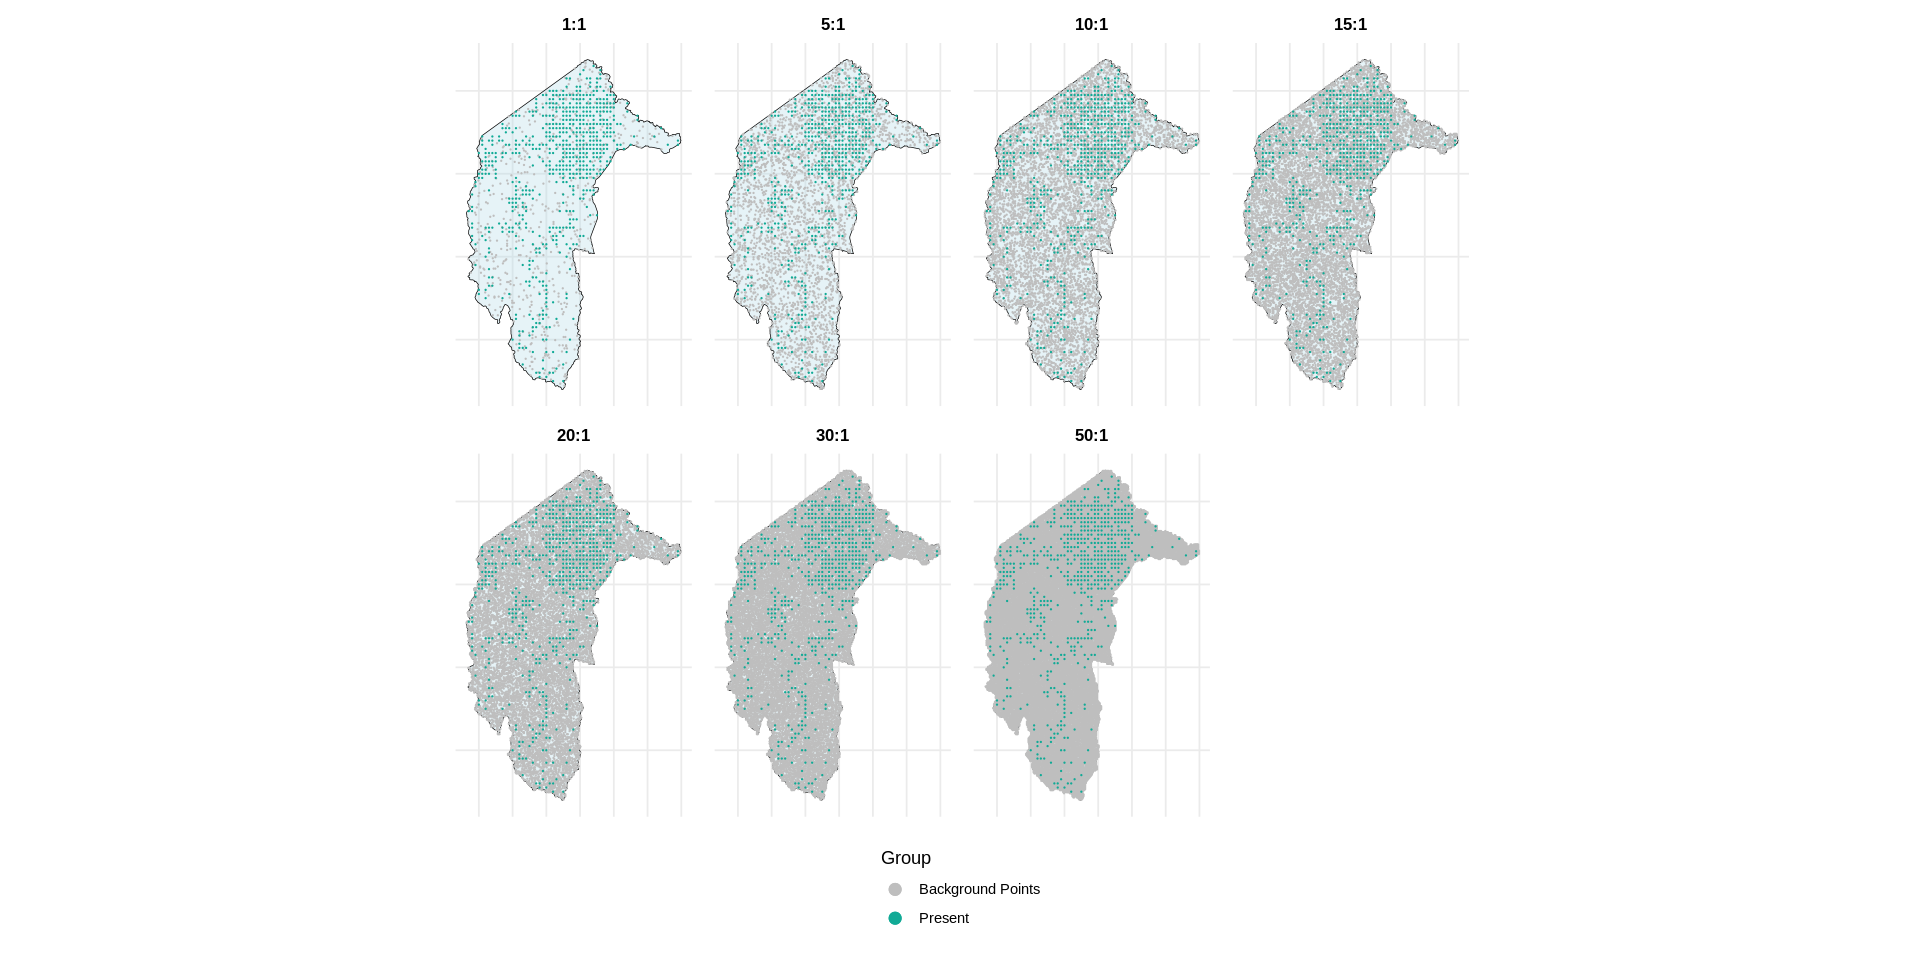

In [11]:

create_map_plot <- function(bg_sf, title, point_size = 0.5) {
  # Ensure correct factor levels
  bg_sf$occrrnS <- factor(bg_sf$occrrnS, levels = c("PRESENT", "bg"))

  # Split the data into background and present points
  bg_only <- bg_sf[bg_sf$occrrnS == "bg", ]
  present_only <- bg_sf[bg_sf$occrrnS == "PRESENT", ]

  ggplot() +
    # Add the ACT polygon layer (without including it in the legend)
    geom_sf(data = ACT, fill = "lightblue", color = "black", alpha = 0.3, show.legend = FALSE) +
    # Plot background points first with mapped color
    geom_sf(data = bg_only, aes(color = "Background Points"), size = point_size, show.legend = TRUE) +
    # Plot present points on top with mapped color
    geom_sf(data = present_only, aes(color = "Present"), size = point_size, show.legend = TRUE) +
    # Manual color mapping
    scale_color_manual(
      name = "Group",
      values = c("Present" = "#11aa96", "Background Points" = "grey")
    ) +
    # Legend with larger points
    guides(color = guide_legend(override.aes = list(size = 3))) +
    ggtitle(title) +
    coord_sf(lims_method = "geometry_bbox") +
    theme_minimal() +
    theme(
      legend.position = "right",
      plot.title = element_text(hjust = 0.5, size = 10, face = "bold"),
      axis.title = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank()
    )
}

# Create plots for each background ratio
p1 <- create_map_plot(combined_random_bg_1to1, "1:1", point_size = 0.01)
p2 <- create_map_plot(combined_random_bg_5to1, "5:1", point_size = 0.01)
p3 <- create_map_plot(combined_random_bg_10to1, "10:1", point_size = 0.01)
p4 <- create_map_plot(combined_random_bg_15to1, "15:1", point_size = 0.01)
p5 <- create_map_plot(combined_random_bg_20to1, "20:1", point_size = 0.01)
p6 <- create_map_plot(combined_random_bg_30to1, "30:1", point_size = 0.01)
p7 <- create_map_plot(combined_random_bg_50to1, "50:1", point_size = 0.01)

# Combine the plots with a shared legend at the bottom
combined_plot <- (p1 + p2 + p3 + p4 + p5 + p6 + p7) +
  plot_layout(ncol = 4, guides = "collect") +  # Collects the legend into one
  plot_annotation(theme = theme(legend.position = "bottom"))

combined_plot


Then, we combine occurrence data with environmental variables.


In [12]:
train_data_list <- list(
  combined_random_bg_1to1_env = get_occurrence_data(combined_random_bg_1to1, env_var_stack, dropCols = c(2,3)),
  combined_random_bg_5to1_env = get_occurrence_data(combined_random_bg_1to1, env_var_stack, dropCols = c(2,3)),
  combined_random_bg_10to1_env = get_occurrence_data(combined_random_bg_1to1, env_var_stack, dropCols = c(2,3)),
  combined_random_bg_15to1_env = get_occurrence_data(combined_random_bg_10to1, env_var_stack, dropCols = c(2,3)),
  combined_random_bg_20to1_env = get_occurrence_data(combined_random_bg_1to1, env_var_stack, dropCols = c(2,3)),
  combined_random_bg_30to1_env = get_occurrence_data(combined_random_bg_1to1, env_var_stack, dropCols = c(2,3)),
  combined_random_bg_50to1_env = get_occurrence_data(combined_random_bg_50to1, env_var_stack, dropCols = c(2,3))
)

test_data_env <- get_occurrence_data(test_data, env_var_stack, dropCols = c(2,3))



When the ratio of background points to true presences exceeds 1:1—such as 5:1, 10:1, 15:1, 20:1, 30:1, and 50:1—an imbalanced dataset issue is introduced. To address this imbalance, we need to use weighting methods.


In [13]:

# 1) Fit weighted models and extract results
results_list_wt <- lapply(train_data_list, function(train_data) {
  fit_model_and_get_perf_wt(train_data, test_data_env)
})

# 2) Build a data frame by extracting each metric from the results_list_wt
results_table_wt_random <- data.frame(
  AUC              = sapply(results_list_wt, function(x) x$auc),                    # AUROC
  AUPR             = sapply(results_list_wt, function(x) x$aupr),                   # Area Under Precision-Recall Curve
  CORR             = sapply(results_list_wt, function(x) x$corr),                   # Correlation
  Accuracy         = sapply(results_list_wt, function(x) x$metrics_0.5$Accuracy),   # Accuracy at threshold 0.5
  Sensitivity      = sapply(results_list_wt, function(x) x$metrics_0.5$Sensitivity),# Sensitivity (Recall)
  Specificity      = sapply(results_list_wt, function(x) x$metrics_0.5$Specificity),# Specificity
  Precision        = sapply(results_list_wt, function(x) x$metrics_0.5$Precision),  # Precision
  F1               = sapply(results_list_wt, function(x) x$metrics_0.5$F1),         # F1 Score
  Best_Threshold   = sapply(results_list_wt, function(x) x$best_threshold),         # Best threshold based on TSS
  Max_TSS          = sapply(results_list_wt, function(x) x$max_tss),                # Maximum TSS
  Best_Sensitivity = sapply(results_list_wt, function(x) x$best_sensitivity),       # Sensitivity at Best Threshold
  Best_Specificity = sapply(results_list_wt, function(x) x$best_specificity)        # Specificity at Best Threshold
)


Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



Print the results.

In [14]:

# Round numeric values
results_table_wt_random <- results_table_wt_random %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))

# Display as styled HTML table
results_table_wt_random %>%
  kable("html", caption = "Model Evaluation Metrics") %>%
  kable_styling(font_size = 12, full_width = FALSE) %>%
  as.character() %>%  # Convert to HTML string
  IRdisplay::display_html()  # Ensure it renders in the notebook

,AUC,AUPR,CORR,Accuracy,Sensitivity,Specificity,Precision,F1,Best_Threshold,Max_TSS,Best_Sensitivity,Best_Specificity
combined_random_bg_1to1_env,0.580,0.569,0.116,0.562,0.713,0.412,0.548,0.620,0.61,0.154,0.456,0.699
combined_random_bg_5to1_env,0.580,0.569,0.116,0.562,0.713,0.412,0.548,0.620,0.61,0.154,0.456,0.699
combined_random_bg_10to1_env,0.580,0.569,0.116,0.562,0.713,0.412,0.548,0.620,0.61,0.154,0.456,0.699
combined_random_bg_15to1_env,0.568,0.563,0.090,0.537,0.669,0.404,0.529,0.591,0.65,0.176,0.324,0.853
combined_random_bg_20to1_env,0.580,0.569,0.116,0.562,0.713,0.412,0.548,0.620,0.61,0.154,0.456,0.699
combined_random_bg_30to1_env,0.580,0.569,0.116,0.562,0.713,0.412,0.548,0.620,0.61,0.154,0.456,0.699
combined_random_bg_50to1_env,0.571,0.559,0.097,0.533,0.662,0.404,0.526,0.586,0.64,0.162,0.331,0.831


In [15]:

# Round numeric values to 3 decimal places
results_table_wt_random <- results_table_wt_random %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))

# Create and display the styled HTML table
html_table <- results_table_wt_random %>%
  kable("html", caption = "Model Evaluation Metrics") %>%
  kable_styling(font_size = 12, full_width = FALSE)

# Render HTML output in the notebook
display_html(as.character(html_table))


,AUC,AUPR,CORR,Accuracy,Sensitivity,Specificity,Precision,F1,Best_Threshold,Max_TSS,Best_Sensitivity,Best_Specificity
combined_random_bg_1to1_env,0.580,0.569,0.116,0.562,0.713,0.412,0.548,0.620,0.61,0.154,0.456,0.699
combined_random_bg_5to1_env,0.580,0.569,0.116,0.562,0.713,0.412,0.548,0.620,0.61,0.154,0.456,0.699
combined_random_bg_10to1_env,0.580,0.569,0.116,0.562,0.713,0.412,0.548,0.620,0.61,0.154,0.456,0.699
combined_random_bg_15to1_env,0.568,0.563,0.090,0.537,0.669,0.404,0.529,0.591,0.65,0.176,0.324,0.853
combined_random_bg_20to1_env,0.580,0.569,0.116,0.562,0.713,0.412,0.548,0.620,0.61,0.154,0.456,0.699
combined_random_bg_30to1_env,0.580,0.569,0.116,0.562,0.713,0.412,0.548,0.620,0.61,0.154,0.456,0.699
combined_random_bg_50to1_env,0.571,0.559,0.097,0.533,0.662,0.404,0.526,0.586,0.64,0.162,0.331,0.831



### 2.1.1 Results

**(1) Background Ratios up to 10:1**

-   Metrics remain stable with minimal changes, indicating the model is robust to moderate increases in background points.

**(2)** **High Background Ratios (15:1 and 50:1)**

-   Sensitivity and precision decline, leading to lower F1 scores.

-   Specificity improves, but at the cost of missing more true positives.

**(3)** **Overall Performance:**

-   Increasing background points beyond **10:1** introduces diminishing returns and eventually harms model balance.

-   A ratio of **5:1 to 10:1** appears to be a sweet spot, maintaining good sensitivity and specificity without introducing severe imbalances.



### 2.1.2 Summary

**(1)** **Increasing background points beyond a 10:1 ratio does not consistently improve model performance** and may even reduce sensitivity and overall balance.

**(2)** **Moderate background ratios (5:1 to 10:1)** provide a balance between sufficient background sampling and maintaining model sensitivity.

**(3)** **At very high ratios (15:1 and 50:1)**, the model starts favoring background points, leading to poorer detection of presences.



## 2.2 The 'disk' approach



Besides completely random background points, we will also test a 'disk' approach to generate random background point methods within a defined range around present records. As the below figure shown, these rings indicate potential areas where **pseudo-absence points** can be sampled, simulating **absence data** when real absences are unavailable.

![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/Gang_gang_buffer.png)

First, we extract present data from the training dataset.

In [16]:

presence_in_train_data <- train_data[train_data$occrrnS == "PRESENT", ]



The function generating background points in a defined disk round the presence data.


In [17]:

# 1) Generate random-buffer pseudo-absences within a study area
generate_pseudo_absences_random_buffer <- function(presence_in_train_data,
                                                   study_area,
                                                   min_buffer, max_buffer,
                                                   n_points_per_presence,
                                                   seed = 123) {
  set.seed(seed)

  pseudo_list <- lapply(seq_len(nrow(presence_in_train_data)), function(i) {
    # Random distance for this presence point
    random_buffer <- runif(1, min = min_buffer, max = max_buffer)

    # Create the buffer polygon
    buffer_poly <- st_buffer(presence_in_train_data[i, ], dist = random_buffer)

    # Intersect buffer with study_area, so we only sample inside it
    intersection_poly <- st_intersection(buffer_poly, study_area)

    # If there's no overlap, return NULL
    if (st_is_empty(intersection_poly)) {
      return(NULL)
    } else {
      # Sample points inside the intersection
      st_sample(intersection_poly, size = n_points_per_presence, type = "random")
    }
  })

  # Combine into an sfc
  pseudo_sfc <- do.call(c, pseudo_list)

  # If all overlaps were empty, pseudo_sfc is NULL
  if (is.null(pseudo_sfc)) {
    return(NULL)
  }

  # Convert sfc to sf
  pseudo_sf <- st_sf(geometry = pseudo_sfc)

  # Label them as "bg"
  pseudo_sf$occrrnS <- "bg"

  # Keep only the occrrnS column
  pseudo_sf <- pseudo_sf[, "occrrnS", drop = FALSE]
  return(pseudo_sf)
}

# 2) Combine pseudo-absences with original data
generate_and_combine_pseudo_absences <- function(presence_in_train_data,
                                                 train_data,
                                                 study_area,
                                                 min_buffer, max_buffer,
                                                 n_points_per_presence,
                                                 seed = 123,
                                                 target_crs = 4283) {
  # Make sure everything is in the same CRS before buffering/intersecting
  presence_in_train_data <- st_transform(presence_in_train_data, target_crs)
  study_area <- st_transform(study_area, target_crs)

  # Generate pseudo-absence points
  pseudo_sf <- generate_pseudo_absences_random_buffer(
    presence_in_train_data,
    study_area,
    min_buffer, max_buffer,
    n_points_per_presence,
    seed
  )

  # Convert and combine
  original_data <- st_transform(train_data, target_crs)

  # If pseudo_sf is NULL (no overlap found), just return original
  if (is.null(pseudo_sf)) {
    message("No pseudo-absence points generated (buffers might lie outside the study area).")
    return(original_data)
  }

  combined <- rbind(original_data, pseudo_sf)
  return(combined)
}


Generate background points within these ranges around present records of Gang-gang Cockatoo in the training dataset:

-   **Within 500m**

-   **500 - 1000m**

-   **1000 - 1500m**

-   **1500 - 2000m**

-   **More than 2000m**

⚠️ Note: producing random points take few minus. ⚠️


In [18]:

suppressWarnings({ # We want to suppress some irrelevant warnings

  disk_bg_500 <- generate_and_combine_pseudo_absences(
    presence_in_train_data,
    train_data,
    min_buffer = 0,
    max_buffer = 500,
    n_points_per_presence = 1,
    seed = 123,
    study_area = ACT,
    target_crs = 4283
  )

})


In [19]:

suppressWarnings({ # We want to suppress some irrelevant warnings

  disk_bg_500_1000 <- generate_and_combine_pseudo_absences(
    presence_in_train_data,
    train_data,
    min_buffer = 500,
    max_buffer = 1000,
    n_points_per_presence = 1,
    seed = 123,
    study_area = ACT,
    target_crs = 4283
  )

})

In [20]:

suppressWarnings({ # We want to suppress some irrelevant warnings

  disk_bg_1000_1500 <- generate_and_combine_pseudo_absences(
    presence_in_train_data,
    train_data,
    min_buffer = 1000,
    max_buffer = 1500,
    n_points_per_presence = 1,
    seed = 123,
    study_area = ACT,
    target_crs = 4283
  )

})

In [21]:

suppressWarnings({ # We want to suppress some irrelevant warnings

  disk_bg_1500_2000 <- generate_and_combine_pseudo_absences(
    presence_in_train_data,
    train_data,
    min_buffer = 1500,
    max_buffer = 2000,
    n_points_per_presence = 1,
    seed = 123,
    study_area = ACT,
    target_crs = 4283
  )

})

In [22]:

suppressWarnings({ # We want to suppress some irrelevant warnings

  disk_bg_2000 <- generate_and_combine_pseudo_absences(
    presence_in_train_data,
    train_data,
    min_buffer = 2000,
    max_buffer = 10000,
    n_points_per_presence = 1,
    seed = 123,
    study_area = ACT,
    target_crs = 4283
  )

})


Let's plot the generated disk background points.


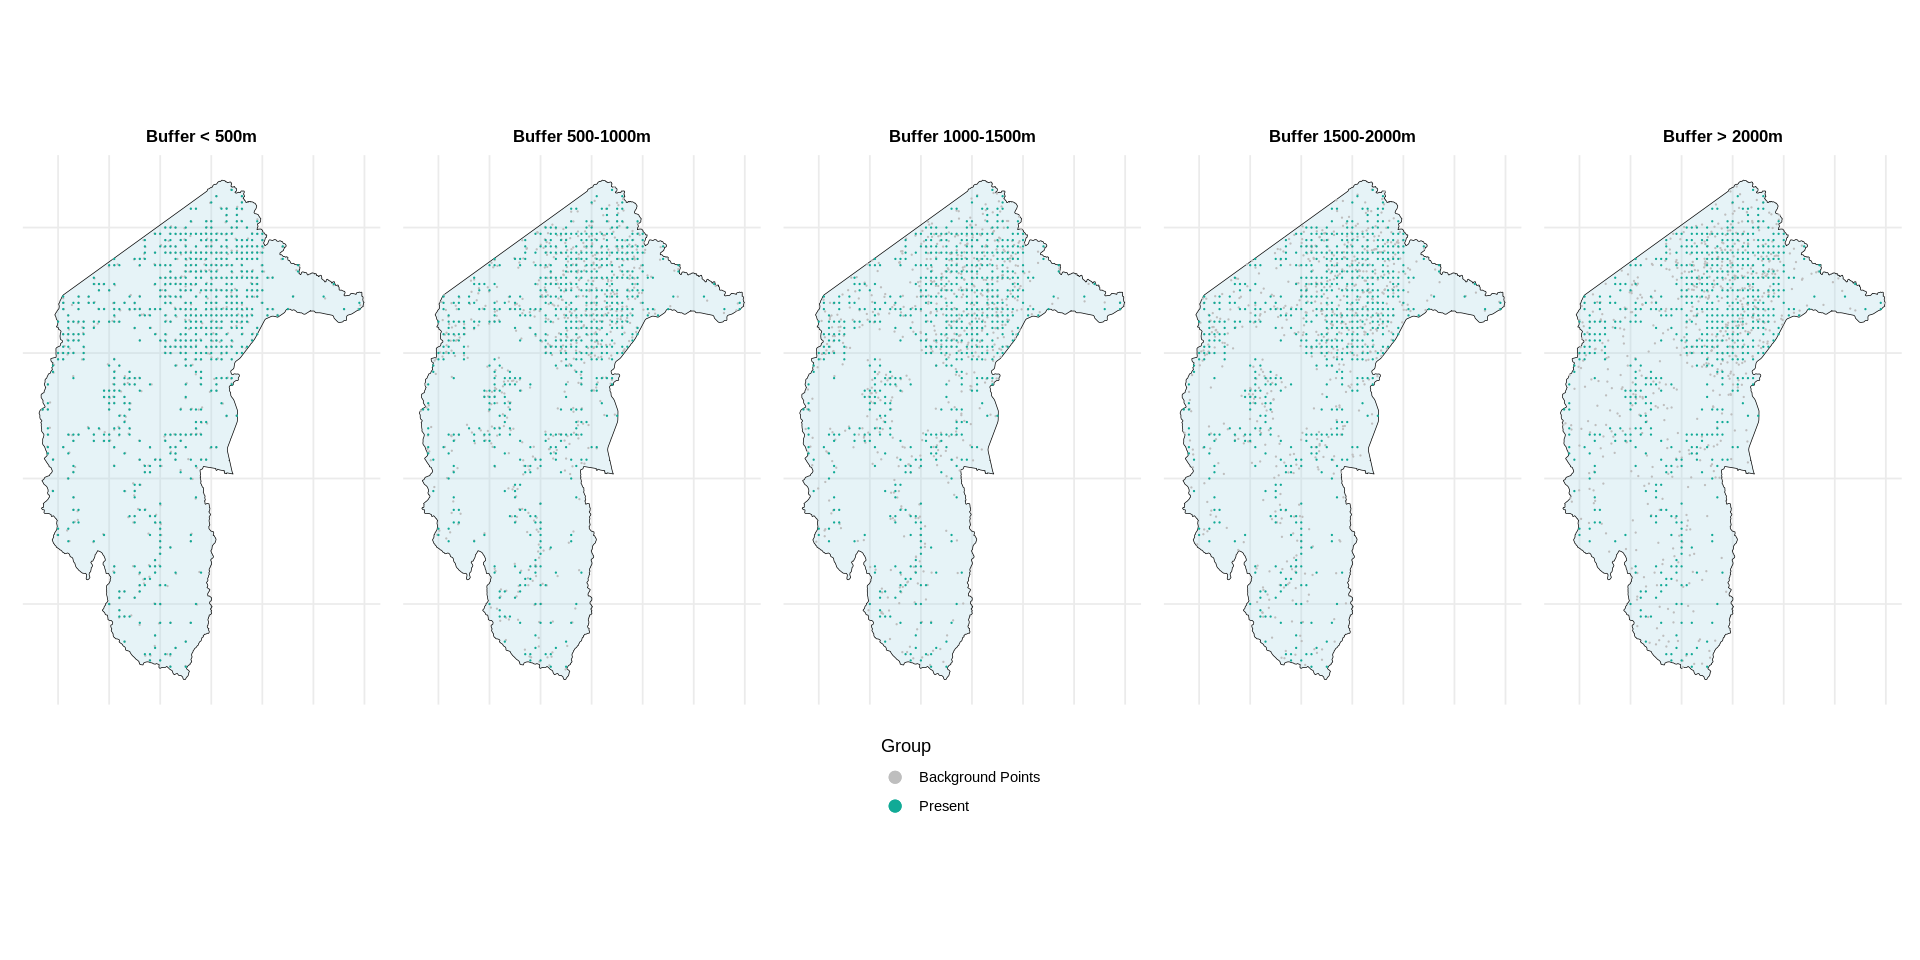

In [23]:

# Create plots for each background ratio with smaller points
p1 <- create_map_plot(disk_bg_500, "Buffer < 500m", point_size = 0.01)
p2 <- create_map_plot(disk_bg_500_1000, "Buffer 500-1000m", point_size = 0.01)
p3 <- create_map_plot(disk_bg_1000_1500, "Buffer 1000-1500m", point_size = 0.01)
p4 <- create_map_plot(disk_bg_1500_2000, "Buffer 1500-2000m", point_size = 0.01)
p5 <- create_map_plot(disk_bg_2000, "Buffer > 2000m", point_size = 0.01)

# Combine the three plots in one row and collect a common legend at the bottom
combined_plot <- (p1 + p2 + p3+ p4 + p5) +
  plot_layout(ncol = 5, guides = "collect") +
  plot_annotation(theme = theme(legend.position = "bottom"))

combined_plot


From the above figure, we can see that as the range increases, the grey points (background points) move farther away from the present points.

Now, let's combine the occurrence data with environmental variables.


In [24]:
train_data_list <- list(
  disk_bg_500_env = get_occurrence_data(disk_bg_500, env_var_stack, dropCols = c(2,3)),
  disk_bg_500_1000_env = get_occurrence_data(disk_bg_500_1000, env_var_stack, dropCols = c(2,3)),
  disk_bg_1000_1500_env = get_occurrence_data(disk_bg_1000_1500, env_var_stack, dropCols = c(2,3)),
  disk_bg_1500_2000_env = get_occurrence_data(disk_bg_1500_2000, env_var_stack, dropCols = c(2,3)),
  disk_bg_2000_env = get_occurrence_data(disk_bg_2000, env_var_stack, dropCols = c(2,3))
)

test_data_env <- get_occurrence_data(test_data, env_var_stack, dropCols = c(2,3))



We can now run the GLM models with these datasets and generate the evaluation metrics. Please note that we created an equal number of background points and present points, so there is no imbalance issue in this case. Thus, we are not using 'wt' in the GLM function.


In [25]:

results_list_no_wt <- lapply(train_data_list, function(train_data) {
  fit_model_and_get_perf_no_wt(train_data, test_data_env)
})


# 2) Build a data frame by extracting each metric from the results_list_wt
results_table_no_wt_disk <- data.frame(
  AUC              = sapply(results_list_no_wt, function(x) x$auc),                    # AUROC
  AUPR             = sapply(results_list_no_wt, function(x) x$aupr),                   # Area Under Precision-Recall Curve
  CORR             = sapply(results_list_no_wt, function(x) x$corr),                   # Correlation
  Accuracy         = sapply(results_list_no_wt, function(x) x$metrics_0.5$Accuracy),   # Accuracy at threshold 0.5
  Sensitivity      = sapply(results_list_no_wt, function(x) x$metrics_0.5$Sensitivity),# Sensitivity (Recall)
  Specificity      = sapply(results_list_no_wt, function(x) x$metrics_0.5$Specificity),# Specificity
  Precision        = sapply(results_list_no_wt, function(x) x$metrics_0.5$Precision),  # Precision
  F1               = sapply(results_list_no_wt, function(x) x$metrics_0.5$F1),         # F1 Score
  Best_Threshold   = sapply(results_list_no_wt, function(x) x$best_threshold),         # Best threshold based on TSS
  Max_TSS          = sapply(results_list_no_wt, function(x) x$max_tss),                # Maximum TSS
  Best_Sensitivity = sapply(results_list_no_wt, function(x) x$best_sensitivity),       # Sensitivity at Best Threshold
  Best_Specificity = sapply(results_list_no_wt, function(x) x$best_specificity)        # Specificity at Best Threshold
)


Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls > cases




Print the results of models.


In [26]:
# Round numeric values to 3 decimal places
results_table_no_wt_disk <- results_table_no_wt_disk %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))

# Generate HTML table
html_table <- results_table_no_wt_disk %>%
  kable("html", caption = "Model Evaluation Metrics") %>%
  kable_styling(font_size = 12, full_width = FALSE)

# Render the HTML in Jupyter
display_html(as.character(html_table))


,AUC,AUPR,CORR,Accuracy,Sensitivity,Specificity,Precision,F1,Best_Threshold,Max_TSS,Best_Sensitivity,Best_Specificity
disk_bg_500_env,0.537,0.542,0.084,0.529,0.471,0.588,0.533,0.500,0.50,0.059,0.471,0.588
disk_bg_500_1000_env,0.573,0.535,0.138,0.577,0.610,0.544,0.572,0.591,0.50,0.154,0.610,0.544
disk_bg_1000_1500_env,0.560,0.526,0.096,0.540,0.471,0.610,0.547,0.506,0.49,0.088,0.801,0.287
disk_bg_1500_2000_env,0.543,0.496,0.072,0.507,0.471,0.544,0.508,0.489,0.49,0.184,0.838,0.346
disk_bg_2000_env,0.569,0.433,-0.111,0.460,0.463,0.456,0.460,0.462,0.47,0.015,0.971,0.044



### 2.2.1 Results

**(1) Moderate Buffers Perform Best:**

-   500 - 1000m buffer had the best AUC (0.582) and F1 (0.594), indicating a good balance between ecological similarity and separation.

**(2)** **Too Close or Too Far Decreases Performance**:

-   Within 500m: Pseudo-absences too close to presences make it hard for the model to distinguish the two.

-   Beyond 2000m: Pseudo-absences too far may not represent relevant environmental contrasts, leading to poor predictions.

**(3)** **Sensitivity vs. Specificity Trade-off:**

-   As background points move farther away, Specificity tends to improve, but Sensitivity decreases, leading to a trade-off between detecting presences and absences.

**(4)** **Correlation Decreases With Distance:**

-   The CORR metric peaks around 500 - 1000m and then declines, even becoming negative beyond 2000m, indicating the model struggles with very distant background points.



### 2.2.3 Summary

**(1) Optimal Buffer Distance:**

-   A moderate buffer (e.g., 500 - 1000m) seems to strike the best balance for pseudo-absence sampling in this context.

**(2)** **Avoid Extremes:**

-   Sampling too close or too far from presence points degrades model performance.




# 3. Conclusion



## 3.1 Comparison across all models

Let's also compare the performance of all good models

In [27]:

# Step 1: Combine the tables
combined_results_table <- bind_rows(
  results_including_true_absence_table_wt,
  results_table_no_wt_disk,
  results_table_wt_random
)

# Step 2: Create the styled HTML table
html_combined_table <- combined_results_table %>%
  kable("html", caption = "Combined Model Evaluation Metrics") %>%
  kable_styling(font_size = 12, full_width = FALSE) %>%
  column_spec(ncol(combined_results_table), bold = TRUE)

# Step 3: Display in Jupyter
display_html(as.character(html_combined_table))


,AUC,AUPR,CORR,Accuracy,Sensitivity,Specificity,Precision,F1,Best_Threshold,Max_TSS,Best_Sensitivity,Best_Specificity
split_90_train,0.679,0.678,0.281,0.607,0.779,0.434,0.579,0.664,0.65,0.295,0.557,0.738
split_70_train,0.697,0.690,0.336,0.647,0.674,0.621,0.640,0.656,0.49,0.295,0.705,0.589
split_50_train,0.670,0.647,0.297,0.588,0.588,0.588,0.588,0.588,0.45,0.324,0.838,0.485
disk_bg_500_env,0.537,0.542,0.084,0.529,0.471,0.588,0.533,0.500,0.50,0.059,0.471,0.588
disk_bg_500_1000_env,0.573,0.535,0.138,0.577,0.610,0.544,0.572,0.591,0.50,0.154,0.610,0.544
disk_bg_1000_1500_env,0.560,0.526,0.096,0.540,0.471,0.610,0.547,0.506,0.49,0.088,0.801,0.287
disk_bg_1500_2000_env,0.543,0.496,0.072,0.507,0.471,0.544,0.508,0.489,0.49,0.184,0.838,0.346
disk_bg_2000_env,0.569,0.433,-0.111,0.460,0.463,0.456,0.460,0.462,0.47,0.015,0.971,0.044
combined_random_bg_1to1_env,0.580,0.569,0.116,0.562,0.713,0.412,0.548,0.620,0.61,0.154,0.456,0.699
combined_random_bg_5to1_env,0.580,0.569,0.116,0.562,0.713,0.412,0.548,0.620,0.61,0.154,0.456,0.699



**(1)** **Best Overall Performance:**

-   **Split Models** show the highest **AUC** scores.

-   **split_70_train** has the best AUC (**0.697**) and CORR (**0.336**), indicating strong predictive performance.

-   **split_90_train** and **split_50_train** follow closely with AUCs of **0.679** and **0.670**, respectively.

**(2)** **Disk Strategy Performance:**

-   Best AUC (**0.582**) achieved with **500–1000m** buffer.

-   **Closer buffers (500m)** result in weaker performance (**AUC = 0.536**), likely due to environmental similarity between presence and background points.

-   **Farther buffers (\>2000m)** degrade performance (**AUC = 0.538**) due to irrelevant background sampling.

**(3)** **Random Strategy Performance:**

-   Stable **AUC (\~0.580)** across most background-to-presence ratios (1:1 to 30:1).

-   Slight performance drop at **50:1 ratio** (**AUC = 0.571**) suggests diminishing returns from adding more background points.

-   **Sensitivity** remains high (\~0.713) across most ratios but at the expense of **Specificity (\~0.412)**.

**(4)** **Best Trade-offs (Max_TSS):**

-   **split_50_train** shows the highest **Max_TSS (0.324)**, indicating the best balance between Sensitivity and Specificity.

-   In Random Strategy, **15:1 ratio** yields the highest **Max_TSS (0.176)**.

**(5)** **Key Insights:**

-   **Split models** outperform both Disk and Random background strategies in terms of AUC and overall predictive ability.

-   **Disk strategy** performs best at moderate buffer distances (**500–1000m**), balancing environmental similarity and separation.

-   **Random strategy** shows stable performance across most ratios, but excessive background points (50:1) can reduce effectiveness.



# 4. Summary

Including true-absence data in models is always beneficial when available. However, simply adding more absence data does not necessarily lead to better model performance.

An imbalance between presence and absence records can negatively impact model accuracy. In such cases, it is important to apply weighting techniques to address this issue and improve predictive performance.

When true absence data is unavailable, pseudo-absence points serve as a useful alternative. The selection strategy for these pseudo-absences should be informed by the ecological characteristics and distribution patterns of the target species.



# References

*for both parts*

Barbet-Massin, M., Jiguet, F., Albert, C., & Thuiller, W. (2012). *Selecting pseudo-absences for species distribution models: How, where and how many? Methods ecol evol 3: 327–338*.

Benkendorf, D. J., Schwartz, S. D., Cutler, D. R., & Hawkins, C. P. (2023). Correcting for the effects of class imbalance improves the performance of machine-learning based species distribution models. *Ecological Modelling*, *483*, 110414.

Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research*, *16*, 321–357.

Chen, C., Liaw, A., Breiman, L., et al. (2004). Using random forest to learn imbalanced data. *University of California, Berkeley*, *110*(1-12), 24.

Elith\*, J., H. Graham\*, C., P. Anderson, R., Dudı́k, M., Ferrier, S., Guisan, A., J. Hijmans, R., Huettmann, F., R. Leathwick, J., Lehmann, A., et al. (2006). Novel methods improve prediction of species’ distributions from occurrence data. *Ecography*, *29*(2), 129–151.

Gaul, W., Sadykova, D., White, H. J., León-Sánchez, L., Caplat, P., Emmerson, M. C., & Yearsley, J. M. (2022). Modelling the distribution of rare invertebrates by correcting class imbalance and spatial bias. *Diversity and Distributions*, *28*(10), 2171–2186.

Johnson, R. A., Chawla, N. V., & Hellmann, J. J. (2012). Species distribution modeling and prediction: A class imbalance problem. *2012 Conference on Intelligent Data Understanding*, 9–16.

Menardi, G., & Torelli, N. (2014). Training and assessing classification rules with imbalanced data. *Data Mining and Knowledge Discovery*, *28*, 92–122.

Phillips, S. J., Anderson, R. P., & Schapire, R. E. (2006). Maximum entropy modeling of species geographic distributions. *Ecological Modelling*, *190*(3-4), 231–259.

Václavı́k, T., & Meentemeyer, R. K. (2009). Invasive species distribution modeling (iSDM): Are absence data and dispersal constraints needed to predict actual distributions? *Ecological Modelling*, *220*(23), 3248–3258.

Valavi, R., Guillera-Arroita, G., Lahoz-Monfort, J. J., & Elith, J. (2022). Predictive performance of presence-only species distribution models: A benchmark study with reproducible code. *Ecological Monographs*, *92*(1), e01486.

Zhang, Z., Mammola, S., & Zhang, H. (2020). Does weighting presence records improve the performance of species distribution models? A test using fish larval stages in the yangtze estuary. *Science of The Total Environment*, *741*, 140393.

![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/EC_section_break.png)

EcoCommons received investment (<https://doi.org/10.3565/chbq-mr75>) from the Australian Research Data Commons (ARDC). The ARDC is enabled by the National Collaborative Research Infrastructure Strategy (NCRIS).

**Our partners**

![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/partners_logos.png)

# **How to Cite EcoCommons**

If you use EcoCommons in your research, please cite the platform as follows:

> EcoCommons Australia 2024. *EcoCommons Australia – a collaborative commons for ecological and environmental modelling*, Queensland Cyber Infrastructure Foundation, Brisbane, Queensland. Available at: <https://data–explorer.app.ecocommons.org.au/> (Accessed: MM DD, YYYY). <https://doi.org/10.3565/chbq-mr75>

You can download the citation file for EcoCommons Australia here: [Download the BibTeX file](reference.bib)